In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

In [ ]:
df = pd.read_excel('/content/Rekap Temuan Produk 2020 - 2025 Terbaru (1).xlsx', sheet_name='temuan kos')
df.head()

,No,Nama Produk,Jenis,Klasifikasi,Kategori,Jumlah,Satuan,Harga Satuan,Harga Total,Nama Sarana,Alamat Sarana,Kabupaten/Kota,Tanggal Entri
0,1,Lameila Eyeshadow,Kosmetik,Kosmetik,TIE (Tanpa Izin Edar),4,Kotak,15000,60000.0,Daisy Store,Jl RSuprapto No 39 Baren Sidoarjo Kabupaten Pa...,Kabupaten Pacitan,2025-09-15 00:00:00
1,2,Lameila Colour Geometry,Kosmetik,Kosmetik,TIE (Tanpa Izin Edar),3,Kotak,15000,45000.0,Daisy Store,Jl RSuprapto No 39 Baren Sidoarjo Kabupaten Pa...,Kabupaten Pacitan,2025-09-15 00:00:00
2,3,Lameila Eyeshadow Makeup Palette,Kosmetik,Kosmetik,TIE (Tanpa Izin Edar),1,Kotak,28000,28000.0,Daisy Store,Jl RSuprapto No 39 Baren Sidoarjo Kabupaten Pa...,Kabupaten Pacitan,2025-09-15 00:00:00
3,4,lameila Ft Color blush,Kosmetik,Kosmetik,TIE (Tanpa Izin Edar),5,Kotak,19000,95000.0,Daisy Store,Jl RSuprapto No 39 Baren Sidoarjo Kabupaten Pa...,Kabupaten Pacitan,2025-09-15 00:00:00
4,5,Lameila all see is you,Kosmetik,Kosmetik,TIE (Tanpa Izin Edar),15,Kotak,25000,375000.0,Daisy Store,Jl RSuprapto No 39 Baren Sidoarjo Kabupaten Pa...,Kabupaten Pacitan,2025-09-15 00:00:00


In [ ]:
df.columns

Index(['No', 'Nama Produk', 'Jenis', 'Klasifikasi', 'Kategori', 'Jumlah',
       'Satuan', 'Harga Satuan', 'Harga Total', 'Nama Sarana', 'Alamat Sarana',
       'Kabupaten/Kota', 'Tanggal Entri'],
      dtype='object')

In [ ]:
import pandas as pd
import numpy as np
import re

col = "Tanggal Entri"

# Salin mentah
raw = df[col].copy()

# 1) Kalau sudah datetime, pakai langsung
parsed = pd.to_datetime(raw, errors="coerce")

# 2) Tangani serial date Excel (angka), hanya untuk yang masih NaT
mask_nat = parsed.isna()

# coba konversi numeric (yang berupa angka atau string angka)
raw_num = pd.to_numeric(raw, errors="coerce")
mask_excel = mask_nat & raw_num.notna()

# Excel date serial: origin 1899-12-30
parsed.loc[mask_excel] = pd.to_datetime(raw_num.loc[mask_excel], unit="D", origin="1899-12-30", errors="coerce")

# 3) Tangani teks campuran (Indonesia/format singkat), hanya untuk yang masih NaT
mask_nat = parsed.isna()

s = raw.astype(str).str.strip()
s = s.replace({"nan": "", "NaN": "", "None": ""})
s = s.apply(lambda x: re.sub(r"\s+", " ", x))

bulan_num = {
    "januari":"01", "februari":"02", "maret":"03", "april":"04",
    "mei":"05", "juni":"06", "juli":"07", "agustus":"08",
    "september":"09", "oktober":"10", "november":"11", "desember":"12"
}

def normalize_to_ddmmyyyy(text: str) -> str:
    t = str(text).strip()
    if t == "":
        return ""
    # kalau sudah ISO-ish (2025-09-15 00:00:00), biarkan
    if re.search(r"^\d{4}-\d{2}-\d{2}", t):
        return t
    # kalau format 15-Sep-25, biarkan (akan diparse di fallback dayfirst)
    if re.search(r"\d{1,2}-[A-Za-z]{3}-\d{2,4}", t):
        return t

    low = t.lower()
    for k, v in bulan_num.items():
        low = re.sub(rf"\b{k}\b", v, low)

    # "24 10 2025" -> "24-10-2025"
    low = re.sub(r"(\d{1,2})\s+(\d{1,2})\s+(\d{4})", r"\1-\2-\3", low)
    return low

clean = s.apply(normalize_to_ddmmyyyy)

# parse teks numeric dd-mm-YYYY terlebih dulu
p1 = pd.to_datetime(clean, errors="coerce", format="%d-%m-%Y")

# fallback: parse umum (dayfirst) untuk 15-Sep-25 dan lainnya
mask2 = p1.isna()
p2 = pd.to_datetime(clean[mask2], errors="coerce", dayfirst=True)

p_final = p1.copy()
p_final.loc[mask2] = p2

# isi ke parsed hanya untuk baris yang masih NaT
parsed.loc[mask_nat] = p_final.loc[mask_nat]

# simpan hasil
df["TANGGAL_ENTRI_PARSED"] = parsed

print("Parsed dtype:", df["TANGGAL_ENTRI_PARSED"].dtype)
print("Valid date:", df["TANGGAL_ENTRI_PARSED"].notna().sum())
print("Invalid (NaT):", df["TANGGAL_ENTRI_PARSED"].isna().sum())

df.loc[df["TANGGAL_ENTRI_PARSED"].isna(), [col]].head(20)

Parsed dtype: datetime64[ns]
Valid date: 369
Invalid (NaT): 0


/tmp/ipython-input-3336117261.py:62: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  p2 = pd.to_datetime(clean[mask2], errors="coerce", dayfirst=True)


,Tanggal Entri


In [ ]:
df

,No,Nama Produk,Jenis,Klasifikasi,Kategori,Jumlah,Satuan,Harga Satuan,Harga Total,Nama Sarana,Alamat Sarana,Kabupaten/Kota,Tanggal Entri,TANGGAL_ENTRI_PARSED
0,1,Lameila Eyeshadow,Kosmetik,Kosmetik,TIE (Tanpa Izin Edar),4,Kotak,15000,60000.0,Daisy Store,Jl RSuprapto No 39 Baren Sidoarjo Kabupaten Pa...,Kabupaten Pacitan,2025-09-15 00:00:00,2025-09-15
1,2,Lameila Colour Geometry,Kosmetik,Kosmetik,TIE (Tanpa Izin Edar),3,Kotak,15000,45000.0,Daisy Store,Jl RSuprapto No 39 Baren Sidoarjo Kabupaten Pa...,Kabupaten Pacitan,2025-09-15 00:00:00,2025-09-15
2,3,Lameila Eyeshadow Makeup Palette,Kosmetik,Kosmetik,TIE (Tanpa Izin Edar),1,Kotak,28000,28000.0,Daisy Store,Jl RSuprapto No 39 Baren Sidoarjo Kabupaten Pa...,Kabupaten Pacitan,2025-09-15 00:00:00,2025-09-15
3,4,lameila Ft Color blush,Kosmetik,Kosmetik,TIE (Tanpa Izin Edar),5,Kotak,19000,95000.0,Daisy Store,Jl RSuprapto No 39 Baren Sidoarjo Kabupaten Pa...,Kabupaten Pacitan,2025-09-15 00:00:00,2025-09-15
4,5,Lameila all see is you,Kosmetik,Kosmetik,TIE (Tanpa Izin Edar),15,Kotak,25000,375000.0,Daisy Store,Jl RSuprapto No 39 Baren Sidoarjo Kabupaten Pa...,Kabupaten Pacitan,2025-09-15 00:00:00,2025-09-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
364,2053,Gucci Parfume,Kosmetik,Kosmetik,TIE (Tanpa Izin Edar),1,Botol,13000.00,13000.0,Skincare Murahku,Jl Kenanga Gang Carik No23 Oro oro Ombo Kec Ba...,Kota Batu,20 Januari 2025,2025-01-20
365,2054,Green Tea Parfume,Kosmetik,Kosmetik,TIE (Tanpa Izin Edar),1,Botol,"250 days, 0:00:00",NaN,Skincare Murahku,Jl Kenanga Gang Carik No23 Oro oro Ombo Kec Ba...,Kota Batu,20 Januari 2025,2025-01-20
366,2055,Vanilla Popcorn Parfume,Kosmetik,Kosmetik,TIE (Tanpa Izin Edar),6,Botol,"250 days, 0:00:00",36000.0,Skincare Murahku,Jl Kenanga Gang Carik No23 Oro oro Ombo Kec Ba...,Kota Batu,20 Januari 2025,2025-01-20
367,2056,Caramel Cookies Parfume,Kosmetik,Kosmetik,TIE (Tanpa Izin Edar),11,Botol,"250 days, 0:00:00",66000.0,Skincare Murahku,Jl Kenanga Gang Carik No23 Oro oro Ombo Kec Ba...,Kota Batu,20 Januari 2025,2025-01-20


In [ ]:
df["Bulan"] = df["TANGGAL_ENTRI_PARSED"].dt.to_period("M").astype(str)

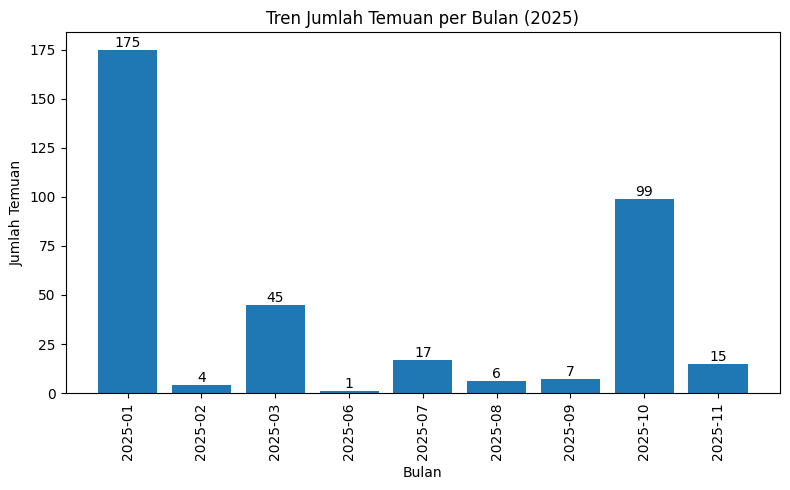

In [ ]:
monthly = (
    df.groupby("Bulan")
      .size()
      .reset_index(name="jumlah_temuan")
      .sort_values("Bulan"))

plt.figure(figsize=(8, 5))
bars = plt.bar(monthly["Bulan"], monthly["jumlah_temuan"])
plt.title("Tren Jumlah Temuan per Bulan (2025)")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Temuan")
plt.xticks(rotation=90, ha="center")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
# pastikan datetime
df = df.dropna(subset=["TANGGAL_ENTRI_PARSED"]).copy()

iso = df["TANGGAL_ENTRI_PARSED"].dt.isocalendar()
df["minggu"] = iso["year"].astype(str) + "-W" + iso["week"].astype(str).str.zfill(2)

weekly = (
    df.groupby("minggu")
      .size()
      .reset_index(name="jumlah_temuan")
      .sort_values("minggu")  # penting biar urut waktunya
      .reset_index(drop=True)
)
weekly.head()

,minggu,jumlah_temuan
0,2025-W02,8
1,2025-W04,167
2,2025-W06,2
3,2025-W07,2
4,2025-W10,3


In [ ]:
weekly2 = weekly.copy()

x = weekly2["jumlah_temuan"].astype(float)

median = x.median()
mad = (x - median).abs().median()

weekly2["robust_z"] = 0.0
if mad != 0:
    weekly2["robust_z"] = (x - median) / (1.4826 * mad)

threshold = 3
weekly2["anomali"] = (weekly2["robust_z"].abs() >= threshold).astype(int)

weekly2.sort_values("robust_z", ascending=False).head(10)

,minggu,jumlah_temuan,robust_z,anomali
1,2025-W04,167,27.148253,1
17,2025-W44,46,6.744908,1
6,2025-W12,36,5.058681,1
15,2025-W40,34,4.721435,1
16,2025-W43,24,3.035208,1
18,2025-W45,10,0.674491,0
9,2025-W29,10,0.674491,0
0,2025-W02,8,0.337245,0
5,2025-W11,6,0.000000,0
14,2025-W38,6,0.000000,0


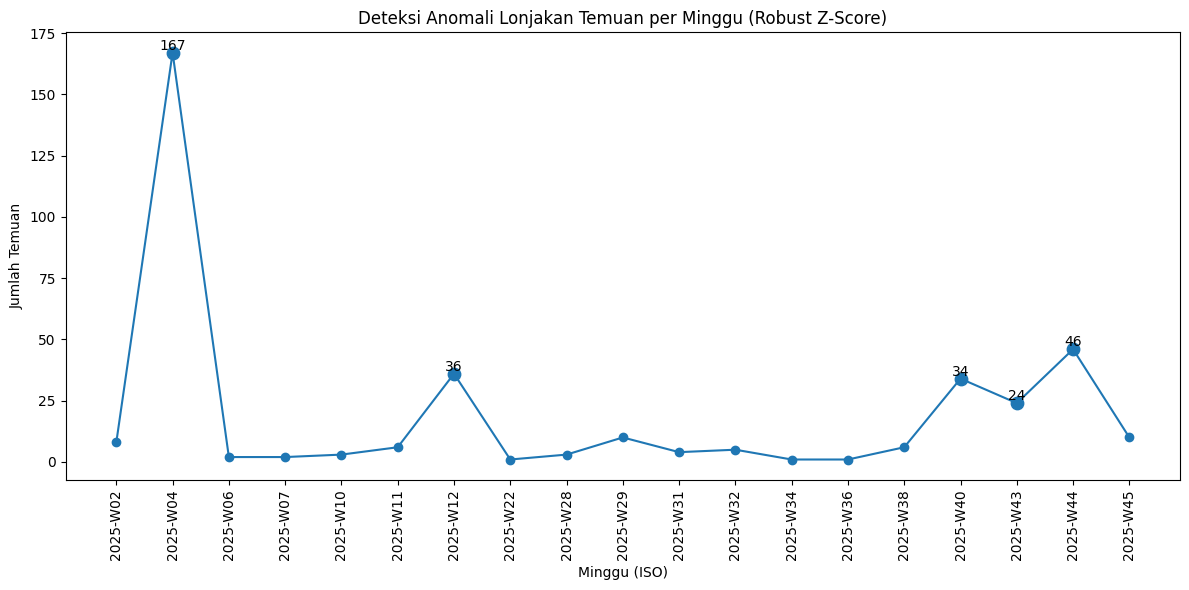

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(weekly2["minggu"], weekly2["jumlah_temuan"], marker="o")

anom = weekly2[weekly2["anomali"] == 1]
plt.scatter(anom["minggu"], anom["jumlah_temuan"], s=80)

# kasih label angka di titik anomali (opsional tapi membantu)
for _, r in anom.iterrows():
    plt.text(r["minggu"], r["jumlah_temuan"], str(int(r["jumlah_temuan"])), va="bottom", ha="center")

plt.title("Deteksi Anomali Lonjakan Temuan per Minggu (Robust Z-Score)")
plt.xlabel("Minggu (ISO)")
plt.ylabel("Jumlah Temuan")

# supaya label x tidak terlalu penuh (ambil tiap 2 minggu)
step = max(len(weekly2)//20, 1)
plt.xticks(weekly2["minggu"][::step], rotation=90)

plt.tight_layout()
plt.show()

Pada minggu-minggu tersebut terjadi peningkatan signifikan arus masuk pencatatan temuan. Ini dapat mencerminkan intensifikasi kegiatan pengawasan/operasi, peningkatan temuan lapangan yang kemudian diinput, atau batch input/backlog yang diselesaikan pada periode tersebu

In [ ]:
weekly_anomali = weekly2[weekly2["anomali"] == 1].copy()
weekly_anomali

,minggu,jumlah_temuan,robust_z,anomali
1,2025-W04,167,27.148253,1
6,2025-W12,36,5.058681,1
15,2025-W40,34,4.721435,1
16,2025-W43,24,3.035208,1
17,2025-W44,46,6.744908,1


In [ ]:
anom_weeks = ["2025-W39","2025-W40","2025-W41","2025-W43","2025-W44","2025-W45"]
df_anom = df[df["minggu"].isin(anom_weeks)].copy()

# contoh hotspot wilayah
kota_col = "Kabupaten/Kota"  # ganti sesuai kolom kamu
df_anom[kota_col].value_counts().head(10)

,count
Kabupaten/Kota,
Kota Surabaya,28
Kabupaten Pasuruan,28
Kota Pasuruan,13
Kota Probolinggo,12
Kabupaten Sidoarjo,10
Kota Madiun,5
Kabupaten Gresik,5
Kabupaten Tuban,4
Kabupaten Pamekasan,3


In [ ]:
df_anom["Jenis"].value_counts().head(10)

,count
Jenis,
Kosmetik,114


In [ ]:
df_anom["Kategori"].value_counts().head(10)

,count
Kategori,
TIE (Tanpa Izin Edar),67
ED (Expire Date / Kedaluwarsa),32
Mengandung bahan berbahaya/bahan dilarang (berdasarkan SE),8
"TIE (Tanpa Izin Edar), ED (Expire Date / Kedaluwarsa)",7


“Berdasarkan deteksi anomali menggunakan Robust Z-Score pada jumlah temuan yang dicatat per minggu (berdasarkan Tanggal Entri), ditemukan periode lonjakan signifikan pada minggu ISO 2025-W39 hingga 2025-W45. Minggu 2025-W43 merupakan puncak lonjakan dengan 306 entri temuan dan terklasifikasi sebagai anomali paling ekstrem. Temuan ini menunjukkan adanya peningkatan arus masuk pencatatan temuan pada periode tersebut, yang perlu ditindaklanjuti melalui analisis hotspot wilayah dan kategori dominan guna mendukung perencanaan pengawasan dan alokasi sumber daya.”

Mingguan itu dipakai karena:

Lebih sensitif menangkap lonjakan mendadak

Cocok untuk mendeteksi:

operasi pengawasan intensif

batch input/backlog

kejadian khusus (razia, sweeping, dll.)

Kalau kamu langsung pakai bulanan:

lonjakan bisa “ketutup” karena dirata-ratakan sebulan

anomali ekstrem seperti W43 (306) bisa terlihat “normal” di level bulan

👉 Jadi:

In [ ]:
weekly_if = weekly.copy().sort_values("minggu").reset_index(drop=True)
Xw = weekly_if[["jumlah_temuan"]].astype(float).values

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=500,
    contamination=0.15,   # ubah 0.10–0.20 sesuai kebutuhan
    random_state=42
)

weekly_if["if_label"] = iso.fit_predict(Xw)  # -1 anomali, 1 normal
weekly_if["anomali_iforest"] = (weekly_if["if_label"] == -1).astype(int)

# score kontinyu (opsional, untuk ranking anomali; makin kecil biasanya makin anomali)
weekly_if["if_score"] = iso.decision_function(Xw)

weekly_if[weekly_if["anomali_iforest"] == 1].sort_values("if_score").head(20)

,minggu,jumlah_temuan,if_label,anomali_iforest,if_score
1,2025-W04,167,-1,1,-0.294624
17,2025-W44,46,-1,1,-0.100149
16,2025-W43,24,-1,1,-0.027867


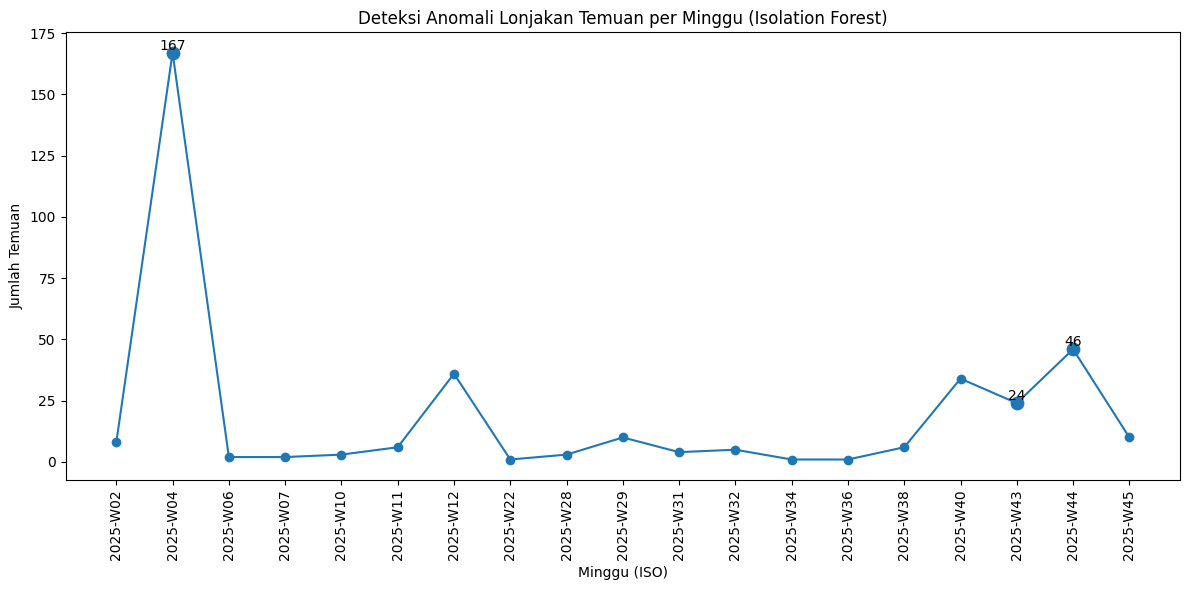

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(weekly_if["minggu"], weekly_if["jumlah_temuan"], marker="o")

anom2 = weekly_if[weekly_if["anomali_iforest"] == 1]
plt.scatter(anom2["minggu"], anom2["jumlah_temuan"], s=80)

# label angka pada titik anomali (biar jelas)
for _, r in anom2.iterrows():
    plt.text(r["minggu"], r["jumlah_temuan"], str(int(r["jumlah_temuan"])), ha="center", va="bottom")

plt.title("Deteksi Anomali Lonjakan Temuan per Minggu (Isolation Forest)")
plt.xlabel("Minggu (ISO)")
plt.ylabel("Jumlah Temuan")

# supaya label x tidak terlalu penuh
step = max(len(weekly_if)//20, 1)
plt.xticks(weekly_if["minggu"][::step], rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
weekly_anom_if = weekly_if[weekly_if["anomali_iforest"] == 1].copy()
weekly_anom_if.sort_values("if_score").head(50)

,minggu,jumlah_temuan,if_label,anomali_iforest,if_score
1,2025-W04,167,-1,1,-0.294624
17,2025-W44,46,-1,1,-0.100149
16,2025-W43,24,-1,1,-0.027867


In [ ]:
kota_col = "Kabupaten/Kota"  # GANTI sesuai kolom kamu

hot_kota = df.groupby(kota_col).size().reset_index(name="jumlah_temuan")
hot_kota = hot_kota.sort_values("jumlah_temuan", ascending=False)

hot_kota.head(15)

,Kabupaten/Kota,jumlah_temuan
19,Kota Surabaya,216
13,Kota Batu,29
9,Kabupaten Pasuruan,28
10,Kabupaten Sidoarjo,16
17,Kota Pasuruan,13
18,Kota Probolinggo,12
4,Kabupaten Malang,8
15,Kota Malang,8
7,Kabupaten Pacitan,7
14,Kota Madiun,5


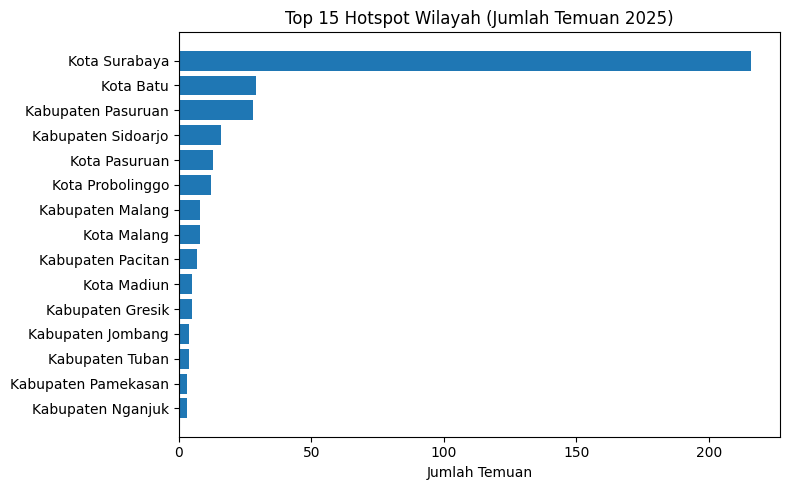

In [ ]:
topn = 15
plt.figure(figsize=(8, 5))
plt.barh(hot_kota.head(topn)[kota_col][::-1], hot_kota.head(topn)["jumlah_temuan"][::-1])
plt.title(f"Top {topn} Hotspot Wilayah (Jumlah Temuan 2025)")
plt.xlabel("Jumlah Temuan")
plt.tight_layout()
plt.show()

In [ ]:
anom_weeks = set(weekly_anomali["minggu"])
df_anom = df[df["minggu"].isin(anom_weeks)].copy()

print("Jumlah record pada minggu anomali:", df_anom.shape[0])
df_anom.head()

Jumlah record pada minggu anomali: 307


,No,Nama Produk,Jenis,Klasifikasi,Kategori,Jumlah,Satuan,Harga Satuan,Harga Total,Nama Sarana,Alamat Sarana,Kabupaten/Kota,Tanggal Entri,TANGGAL_ENTRI_PARSED,Bulan,minggu
23,24,iv infus multivita injection,Kosmetik,Kosmetik,TIE (Tanpa Izin Edar),8,Botol,150000,1200000.0,Citra Ayu Lestari,Jl Ngagel Madya No 74 Surabaya,Kota Surabaya,24 Oktober 2025,2025-10-24,2025-10,2025-W43
24,25,placenta commpositum,Kosmetik,Kosmetik,TIE (Tanpa Izin Edar),51,Ampul,125000,6375000.0,Citra Ayu Lestari,Jl Ngagel Madya No 74 Surabaya,Kota Surabaya,24 Oktober 2025,2025-10-24,2025-10,2025-W43
25,26,water drop cream,Kosmetik,Kosmetik,TIE (Tanpa Izin Edar),9,Botol,60000,540000.0,Citra Ayu Lestari,Jl Ngagel Madya No 74 Surabaya,Kota Surabaya,24 Oktober 2025,2025-10-24,2025-10,2025-W43
26,27,Starcain plus,Kosmetik,Kosmetik,TIE (Tanpa Izin Edar),3,Pot,100000,300000.0,Citra Ayu Lestari,Jl Ngagel Madya No 74 Surabaya,Kota Surabaya,24 Oktober 2025,2025-10-24,2025-10,2025-W43
27,28,dermaceutic foamer 15,Kosmetik,Kosmetik,TIE (Tanpa Izin Edar),3,Botol,200000,600000.0,Citra Ayu Lestari,Jl Ngagel Madya No 74 Surabaya,Kota Surabaya,24 Oktober 2025,2025-10-24,2025-10,2025-W43


In [ ]:
hot_kota_anom = df_anom.groupby(kota_col).size().reset_index(name="jumlah_temuan_anomali")
hot_kota_anom = hot_kota_anom.sort_values("jumlah_temuan_anomali", ascending=False)

hot_kota_anom.head(15)

,Kabupaten/Kota,jumlah_temuan_anomali
11,Kota Surabaya,202
8,Kota Batu,29
4,Kabupaten Pasuruan,23
9,Kota Pasuruan,13
10,Kota Probolinggo,12
5,Kabupaten Sidoarjo,10
0,Kabupaten Gresik,5
7,Kabupaten Tuban,4
2,Kabupaten Nganjuk,3
3,Kabupaten Pamekasan,3


In [ ]:
# GANTI kalau kamu punya kolom-kolom ini
produk_col = "Nama Produk"     # opsional
temuan_col = "Kategori"    # opsional
sarana_col = "Nama Sarana"     # opsional

for col in [produk_col, temuan_col, sarana_col]:
    if col in df_anom.columns:
        top = df_anom[col].value_counts().head(10)
        print(f"\nTop 10 {col} pada minggu anomali:")
        print(top)


Top 10 Nama Produk pada minggu anomali:
Nama Produk
Dryn Krim                               20
Dryn Lotion Acne                         2
Dryn Serum                               2
Dryn Toner Acne                          2
LASTING MATTE LIPCREAM PF-L01 N02        2
Dryn Oily Wash                           2
Victoria s Secret Scandalous Parfume     2
Brightening Eye Gel                      1
Brightening Skin Serum                   1
Brightening Skin Night Cream             1
Name: count, dtype: int64

Top 10 Kategori pada minggu anomali:
Kategori
TIE (Tanpa Izin Edar)                                         244
ED (Expire Date / Kedaluwarsa)                                 32
Lain - Lain                                                    16
Mengandung bahan berbahaya/bahan dilarang (berdasarkan SE)      8
TIE (Tanpa Izin Edar), ED (Expire Date / Kedaluwarsa)           7
Name: count, dtype: int64

Top 10 Nama Sarana pada minggu anomali:
Nama Sarana
Inti Kreasi Indonesia              

In [ ]:
weekly2.to_excel("01_tren_mingguan_dan_anomali_zscore.xlsx", index=False)
monthly.to_excel("02_tren_bulanan.xlsx", index=False)
hot_kota.to_excel("03_hotspot_kota_total_2025.xlsx", index=False)
hot_kota_anom.to_excel("04_hotspot_kota_pada_minggu_anomali.xlsx", index=False)

print("Saved outputs.")

Saved outputs.


Apa yang kamu tulis sebagai “Insight Kebijakan” (format siap pakai)

Nanti berdasarkan output Step 4–7, kamu tulis pola seperti:

Hot period
“Terdapat lonjakan temuan pada minggu [X], ditandai robust z-score ≥ 3, yang mengindikasikan anomali dibanding pola mingguan normal.”

Hotspot wilayah
“Pada periode anomali, konsentrasi temuan paling tinggi berasal dari wilayah [Kota A, Kota B], sehingga alokasi sumber daya pengawasan perlu diprioritaskan di wilayah tersebut.”

Dominan jenis/produk/sarana saat lonjakan
“Lonjakan terutama didorong oleh [jenis temuan/jenis produk/sarana tertentu], sehingga intervensi kebijakan dapat difokuskan pada peningkatan pembinaan/monitoring pada kategori tersebut.”

In [ ]:
set_z = set(weekly2.loc[weekly2["anomali"] == 1, "minggu"])
set_if = set(weekly_if.loc[weekly_if["anomali_iforest"] == 1, "minggu"])

print("Anomali Z-score:", set_z)
print("Anomali Isolation Forest:", set_if)
print("Irisan:", set_z & set_if)


Anomali Z-score: {'2025-W12', '2025-W44', '2025-W40', '2025-W04', '2025-W43'}
Anomali Isolation Forest: {'2025-W44', '2025-W04', '2025-W43'}
Irisan: {'2025-W44', '2025-W04', '2025-W43'}


Apa arti hasil tersebut?
1️⃣ Robust Z-Score (statistika robust)

Mendeteksi 5 minggu anomali:

2025-W04

2025-W12

2025-W40

2025-W43

2025-W44

Artinya: kelima minggu ini memiliki lonjakan jumlah temuan yang menyimpang signifikan dibanding pola mingguan normal (berdasarkan median dan MAD).

2️⃣ Isolation Forest (unsupervised validation)

Mendeteksi 3 minggu anomali:

2025-W04

2025-W43

2025-W44

Artinya: tiga minggu ini memiliki pola jumlah temuan yang paling tidak lazim secara global, bukan hanya tinggi secara absolut.

3️⃣ Irisan kedua metode (ini yang paling penting)

Irisan =
{'2025-W04', '2025-W43', '2025-W44'}

Maknanya:

Tiga minggu ini konsisten terdeteksi sebagai anomali oleh dua pendekatan berbeda

Ini adalah periode anomali yang paling kuat secara evidensial

Secara metodologi, ini disebut strong anomalies

Apakah wajar hasilnya tidak sama?

✅ Sangat wajar. Bahkan ideal.

Robust Z-Score → sensitif terhadap lonjakan ekstrem secara statistik

Isolation Forest → selektif, hanya menandai pola yang benar-benar “asing”

Kalau hasilnya 100% sama, justru mencurigakan karena dua metode bekerja dengan prinsip berbeda.

Mana yang dipakai untuk hotspot kebijakan?

Jawaban akademiknya:

Robust Z-Score → dasar utama penentuan periode anomali

Isolation Forest → validasi pendukung

Irisan dua metode → prioritas tertinggi untuk analisis hotspot dan implikasi kebijakan

Kalimat siap tempel ke laporan

“Hasil deteksi anomali menunjukkan bahwa metode Robust Z-Score mengidentifikasi lima minggu anomali, sedangkan Isolation Forest mendeteksi tiga minggu anomali. Terdapat irisan pada minggu 2025-W04, 2025-W43, dan 2025-W44 yang terdeteksi sebagai anomali oleh kedua metode. Minggu-minggu tersebut diperlakukan sebagai periode anomali yang paling kuat secara evidensial dan dijadikan fokus utama dalam analisis lanjutan terhadap konsentrasi wilayah, kategori temuan, dan sarana.”